In [1]:
import pandas as pd
import scipy.stats
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from aquacrop import AquaCropModel, Soil, Crop, InitialWaterContent,IrrigationManagement
import Aq_Optimization_functons
from Aq_Optimization_functons import *
import warnings
import time
warnings.filterwarnings("ignore")
from plot_functions import *
import time
%load_ext autoreload
%autoreload 2

/Users/m089r172/anaconda3/envs/aqua/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [7]:
# pip install git+https://github.com/wndlovu/aquacrop
plt.rcParams["figure.dpi"] = 500

In [3]:
start_time = time.time()
# PSO 3 opt. params
# =============
# all_yld_df, simul_reported, all_ET_df   = for_objf (smt =[30, 50.472, 62.692, 49.887],CCx = 0.851,
#                                          WP = 33.141, Kcb =1.0000010482, HI0 = 0.55, a_HI = 7.37247, Zmax = 2.4364,no_et = True, df_type ="test")    #PSO_train


# all_yld_df, simul_reported, all_ET_df   = for_objf (smt =[30, 50.46429813, 61.02248025, 42.30723166],CCx = 0.885556642,
#                                          WP = 32.27125759, Kcb =1, HI0 = 0.55, a_HI = 1.586909385, Zmax = 1.753598564,no_et = True, df_type ="train")

# all_yld_df, simul_reported, all_ET_df   = for_objf (smt =[30, 50, 62.32858011, 49.35386929],CCx = 0.850301429,
#                                          WP = 33.16898916, Kcb =1, HI0 = 0.55, a_HI = 3.221713012, Zmax = 2.259297081,no_et = True, df_type ="test")


# NSGA-II
# =============
# bst irrig
# all_yld_df, simul_reported, all_ET_df  = for_objf (smt =[54.814844,30.000007,  46.213611,59.364884],CCx =0.954401, WP = 30.820504, Kcb =1.056756,
#                                                 HI0 = 0.513886, a_HI =0.500047, Zmax =1.201175,df_type ="test", no_et = True)

#middle nsga
# all_yld_df, simul_reported, all_ET_df  = for_objf (smt =[46.642431,47.607506, 44.439728,59.829289],CCx =0.973186, WP = 31.946701, Kcb =1.057744,
#                                                 HI0 = 0.495800, a_HI =0.557917, Zmax =1.200949, df_type ="test", no_et = True)  
# best yield

# all_yld_df, simul_reported, all_ET_df  = for_objf (smt =[41.494875, 30.050285, 34.479966, 58.861757],CCx =0.965120, WP = 31.633690, Kcb =1.027712,
#                                                 HI0 = 0.517828, a_HI =1.906190, Zmax =1.217361,df_type ="test", no_et = True)  #with 2012 and wc

# middle benchmark
# ==========
all_yld_df, simul_reported, all_ET_df  = for_objf (smt =[40,45,45,45],CCx =0.92, WP = 32.5, Kcb =1.05,              #middle point
                                                HI0 = 0.5, a_HI =5.25, Zmax =1.6,df_type ="full", no_et  = True) 


simul_reported.rename(columns={"Seasonal irrigation (mm)": "Simulated_Irrigation", "Yield (tonne/ha)": "Simulated_Yield"},inplace =True)

# Add a new column 'field_region' based on the 'FieldID'
simul_reported["field_region"] = np.where(simul_reported["FieldID"].str.startswith("SW"), "SW",
                               np.where(simul_reported["FieldID"].str.startswith(("NW", "NB")), "NW",
                               np.where(simul_reported["FieldID"].str.startswith("WC"), "WC",
                               np.where(simul_reported["FieldID"].str.startswith("NC"), "NC", "Unknown"))))
simul_reported.head(3)


end_time = time.time()
elapsed_time = end_time - start_time

print(f"Time elapsed for parallel evaluation: {elapsed_time:.2f} seconds")   


116
without_ET: 116
Time elapsed for parallel evaluation: 23.48 seconds


## Train data

In [3]:
traindata = simul_reported [["Year", "FieldID", "Simulated_Yield","Reported_Yield","Simulated_Irrigation","Reported_Irrigation" ]]
traindata["Dataset"] = 'train'
traindata.head(2)


,Year,FieldID,Simulated_Yield,Reported_Yield,Simulated_Irrigation,Reported_Irrigation,Dataset
0,2019,WC2,12.174594,NaN,312.000,283.718,train
1,2019,WC3,12.147737,NaN,288.544,288.544,train


In [8]:
traindata.loc[traindata["FieldID"] == "SW1"]

,Year,FieldID,Simulated_Yield,Reported_Yield,Simulated_Irrigation,Reported_Irrigation,Dataset
85,2016,SW1,11.277157,NaN,456.000000,437.748448,train
86,2017,SW1,12.346823,NaN,408.000000,405.270174,train
87,2018,SW1,11.550819,NaN,384.000000,436.754370,train
88,2019,SW1,12.167300,NaN,408.000000,409.618317,train
89,2020,SW1,10.559582,NaN,588.408179,588.408179,train
90,2022,SW1,7.700401,NaN,588.408179,524.066290,train


## Test data

In [5]:
testdata = simul_reported [["Year", "FieldID", "Simulated_Yield","Reported_Yield","Simulated_Irrigation","Reported_Irrigation" ]]
testdata["Dataset"] = 'test'
testdata

,Year,FieldID,Simulated_Yield,Reported_Yield,Simulated_Irrigation,Reported_Irrigation,Dataset
0,2018,WC1,12.480121,NaN,228.000000,273.812000,test
1,2020,WC1,11.846674,NaN,516.000000,360.680000,test
2,2019,WC6,12.254947,NaN,300.000000,294.640000,test
3,2016,WC5,12.347823,NaN,264.000000,391.160000,test
4,2020,WC5,10.366127,NaN,391.160000,370.078000,test
5,2017,NB1,12.410636,10.184502,312.000000,297.575357,test
6,2019,WC25,12.190214,NaN,300.000000,321.564000,test
7,2019,NW1,12.319194,14.074976,264.000000,309.232497,test
8,2021,NW1,12.100762,11.608880,408.000000,366.544504,test
9,2022,NW1,10.185067,9.591348,453.658570,429.969663,test


In [10]:
calculate_metrics_to_dataframe(traindata,d_set ="test", no_et =True)

,iteration,obj_variable,MAE,RMSE,R^2,Pearson r,Data_set,prms
0,1,Irrigation,40.269439,57.678129,0.520535,0.796886,test,prms
1,1,Yield,2.253475,3.315788,-0.421439,0.435820,test,prms


In [17]:
fontsize = 14
def plot_yield_comparison(
    df, 
    x_col: str = 'Reported_Yield', 
    y_col: str = 'Simulated_Yield', 
    df_type: str = "Test", 
    hue: str = None,
    style: str = None,
    metric: bool = True,
    x_axis: str = None,
    y_axis: str = None,
    xlim: tuple = (0, 19), 
    ylim: tuple = (0, 19),
    bound: tuple = None,
    text = None,
    color=None,
    ax=None,
    label_prefix: str = "",
    one_to_one_line: bool = True  # new parameter
) -> tuple:
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    from scipy.stats import pearsonr

    def pbias(observed, predicted):
        return 100 * np.sum( observed - predicted) / np.sum(observed)

    def nmae(predicted, observed):
        return 100 * mean_absolute_error(observed, predicted) / np.mean(observed)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    else:
        fig = None
        
    if color is None:
        color = "red"

    # Optional 1:1 line
    if one_to_one_line:
        ax.axline((0, 0), slope=1, label='1:1 line', color='gray', linestyle='--')

    # Scatter plot
    sns.scatterplot(data=df, x=x_col, y=y_col, hue=hue, ax=ax, color=color, style=style, s=50, edgecolor='k', label=f'{label_prefix} points')

    # Regression line
    sns.regplot(data=df, x=x_col, y=y_col, scatter=False, ci=None, ax=ax, color=color, label=f'{label_prefix} regression line', line_kws={'label': None})

    # Shaded region
    if bound:
        x_range = np.linspace(df[x_col].min(), df[x_col].max(), len(df))
        ax.fill_between(x_range, bound[0], bound[1], color='gray', alpha=0.3, label=f'Y range: {bound[0]} to {bound[1]}')

    # Axis labels and limits
    ax.set_xlabel(x_axis or x_col, fontsize=fontsize)
    ax.set_ylabel(y_axis or y_col, fontsize=fontsize)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Metrics
    observed = df[x_col].values
    predicted = df[y_col].values

    corr, _ = pearsonr(observed, predicted)
    mae = mean_absolute_error(observed, predicted)
    rmse = np.sqrt(mean_squared_error(observed, predicted))
    r2 = r2_score(observed, predicted)
    pbias_value = pbias( observed, predicted)
    nmae_value = nmae(predicted, observed)

    if metric:
        text_x = 0.02 if label_prefix in ["Train", ""] else 0.68
        ax.annotate(
            f"{label_prefix} \n"
            f"RMSE: {rmse:.1f}\n"
            f"PBIAS: {pbias_value:.2f}%\n"
            f"NMAE: {nmae_value:.1f}%\n"
            f"$R^2$: {corr**2:.2f}",
            xy=(text_x, 0.78), xycoords='axes fraction', fontsize=fontsize
        )
    ax.legend(loc='lower right')
    if text is not None:
        
        ax.text(
            0.46, .94, text,
            transform=ax.transAxes,
            ha='center',
            va='bottom',
            fontsize=fontsize  # optional
        )
        
    if fig:
        ax.set_title(f"{df_type}")
        return fig, ax
    return ax


NameError: name 'traindata' is not defined

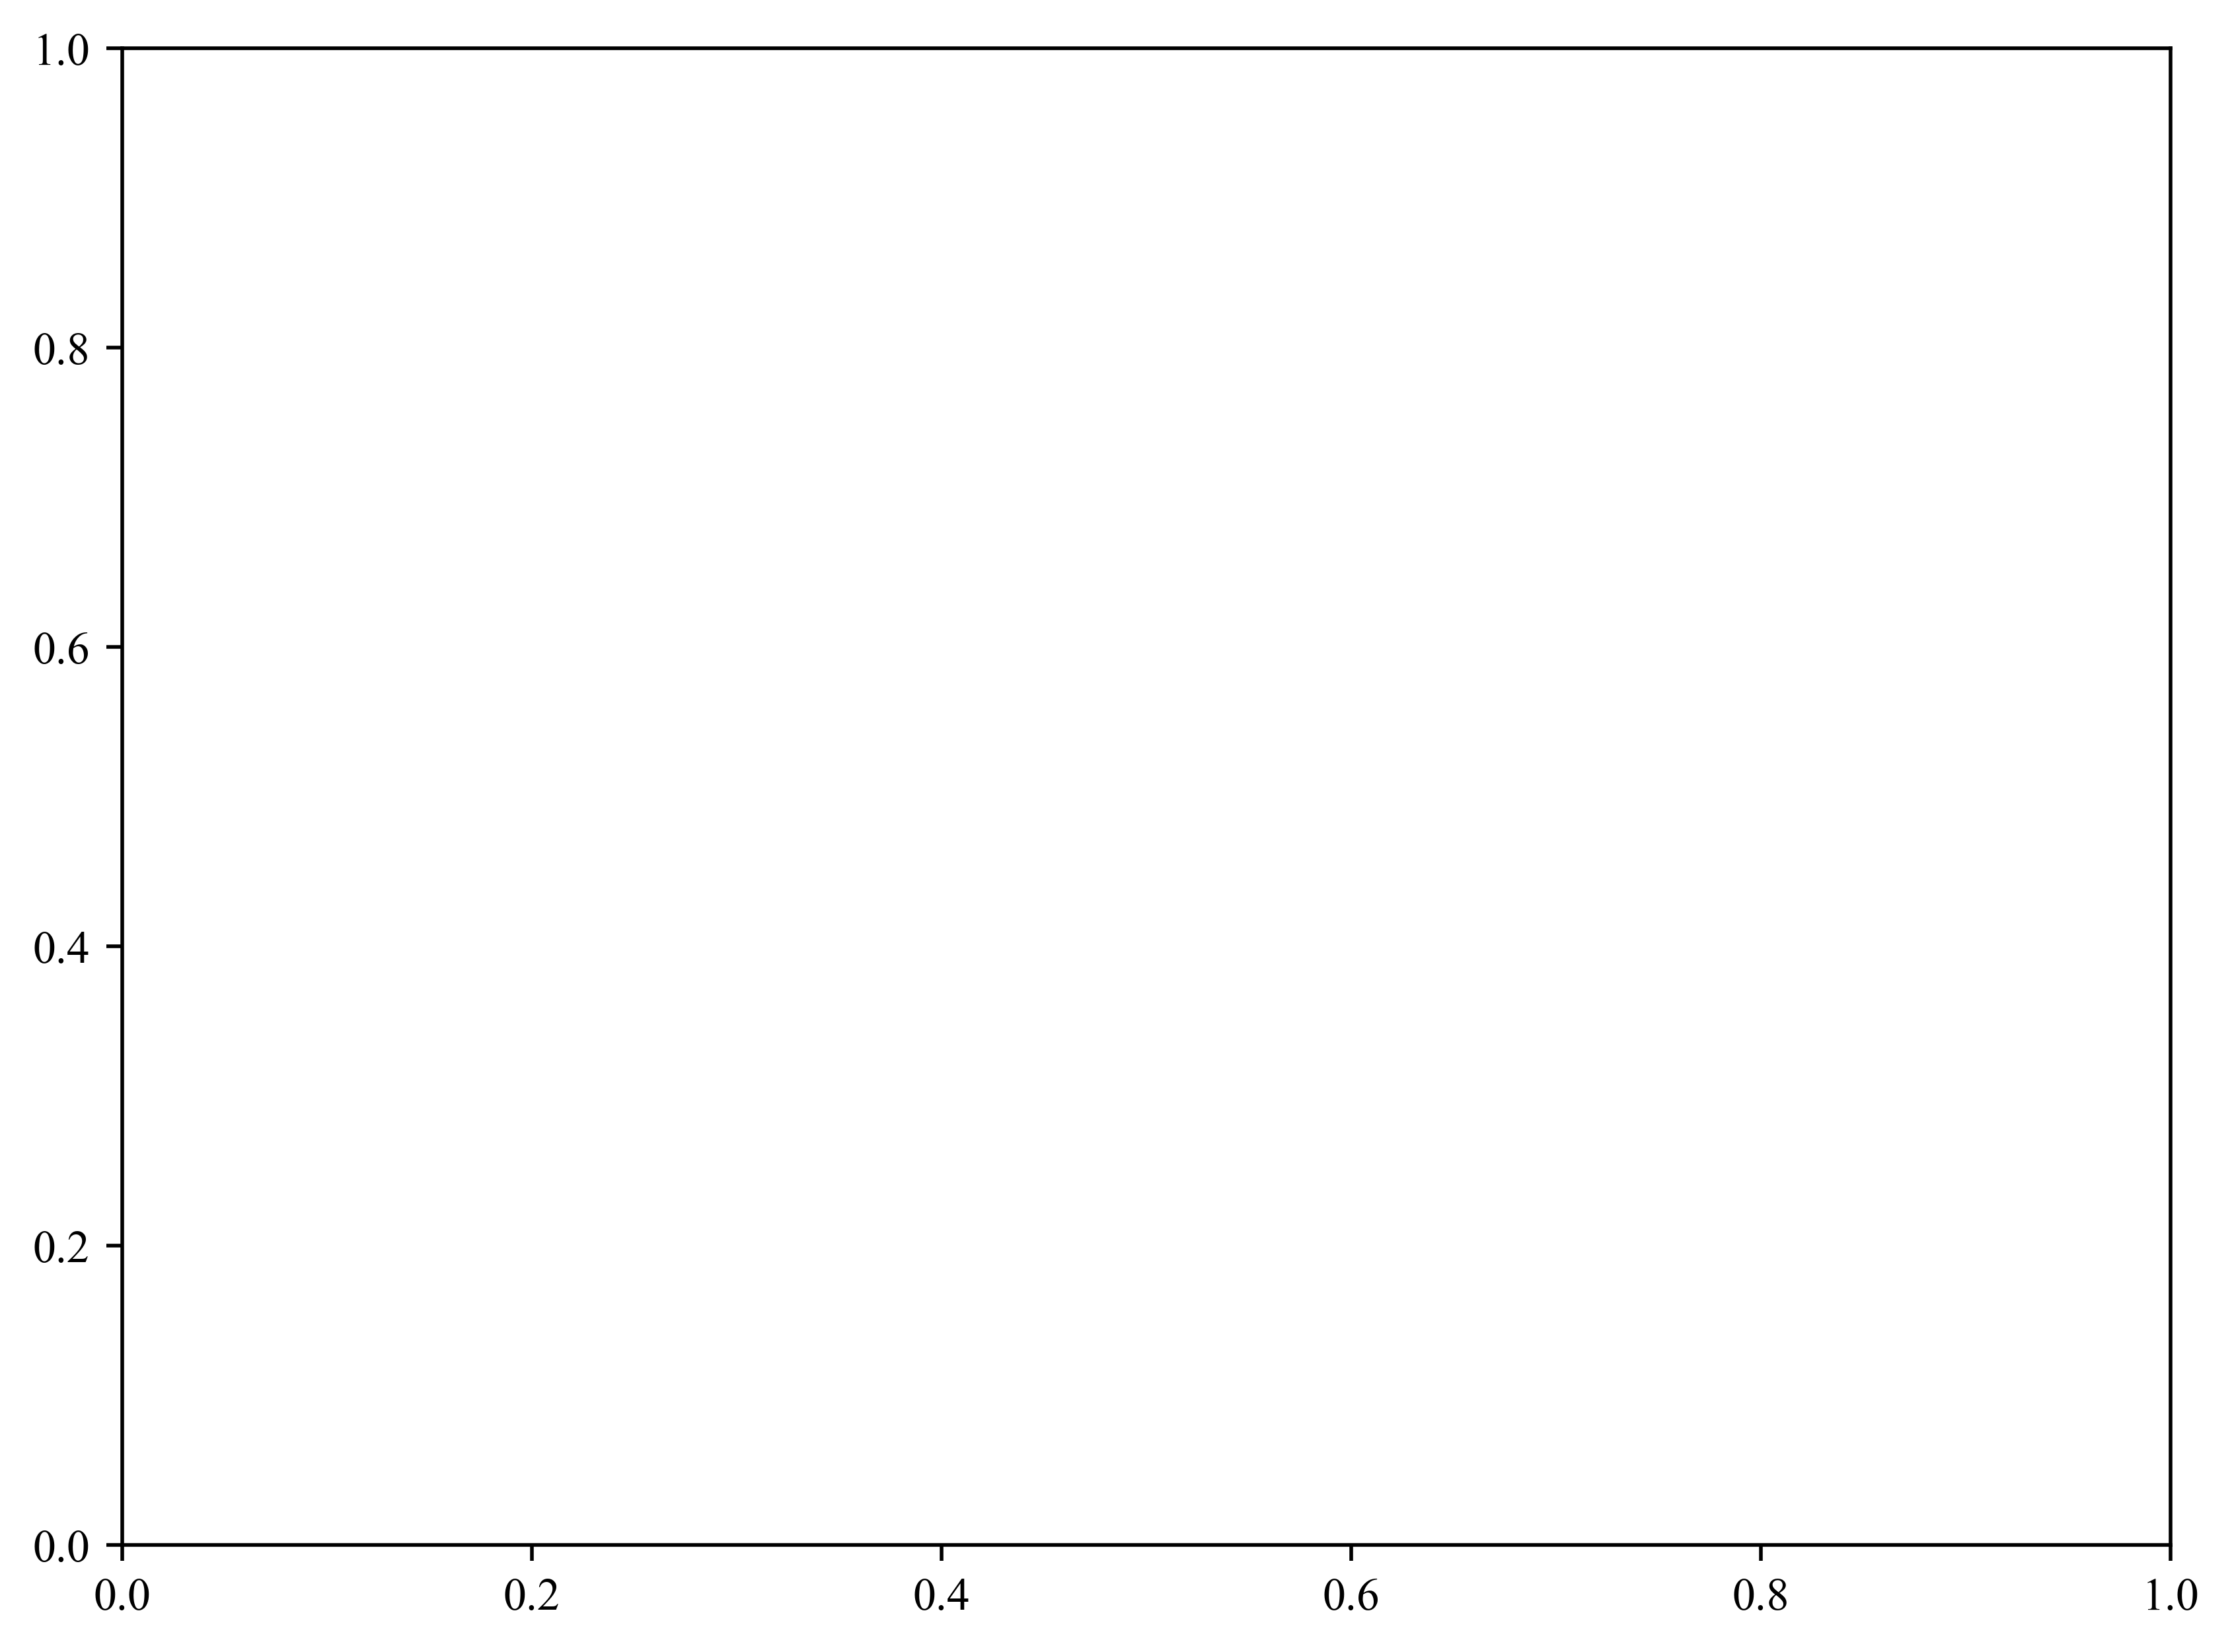

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))



# Plot: Train set (on same ax)
plot_yield_comparison(
    df=traindata.dropna(subset=["Reported_Yield", "Simulated_Yield"]),
    x_col='Reported_Yield',
    y_col='Simulated_Yield',
    text="Yield Optimized",
    x_axis="Reported Yield (t/ha)",  # Repeated for consistency
    y_axis="Simulated Yield (t/ha)",
    color ='blue',
    ax=ax,
    label_prefix="Train"

)

# Plot: Test set
plot_yield_comparison(
    df=testdata.dropna(subset=["Reported_Yield", "Simulated_Yield"]),
    x_col='Reported_Yield',
    y_col='Simulated_Yield',
#     text="Baseline",
    x_axis="Reported Yield (t/ha)",
    y_axis="Simulated Yield (t/ha)",
    ax=ax,
    one_to_one_line = False,
    label_prefix="Test"
)

# plt.title("Simulated vs Reported Yield: Train & Test Sets")
plt.tight_layout()
plt.show()


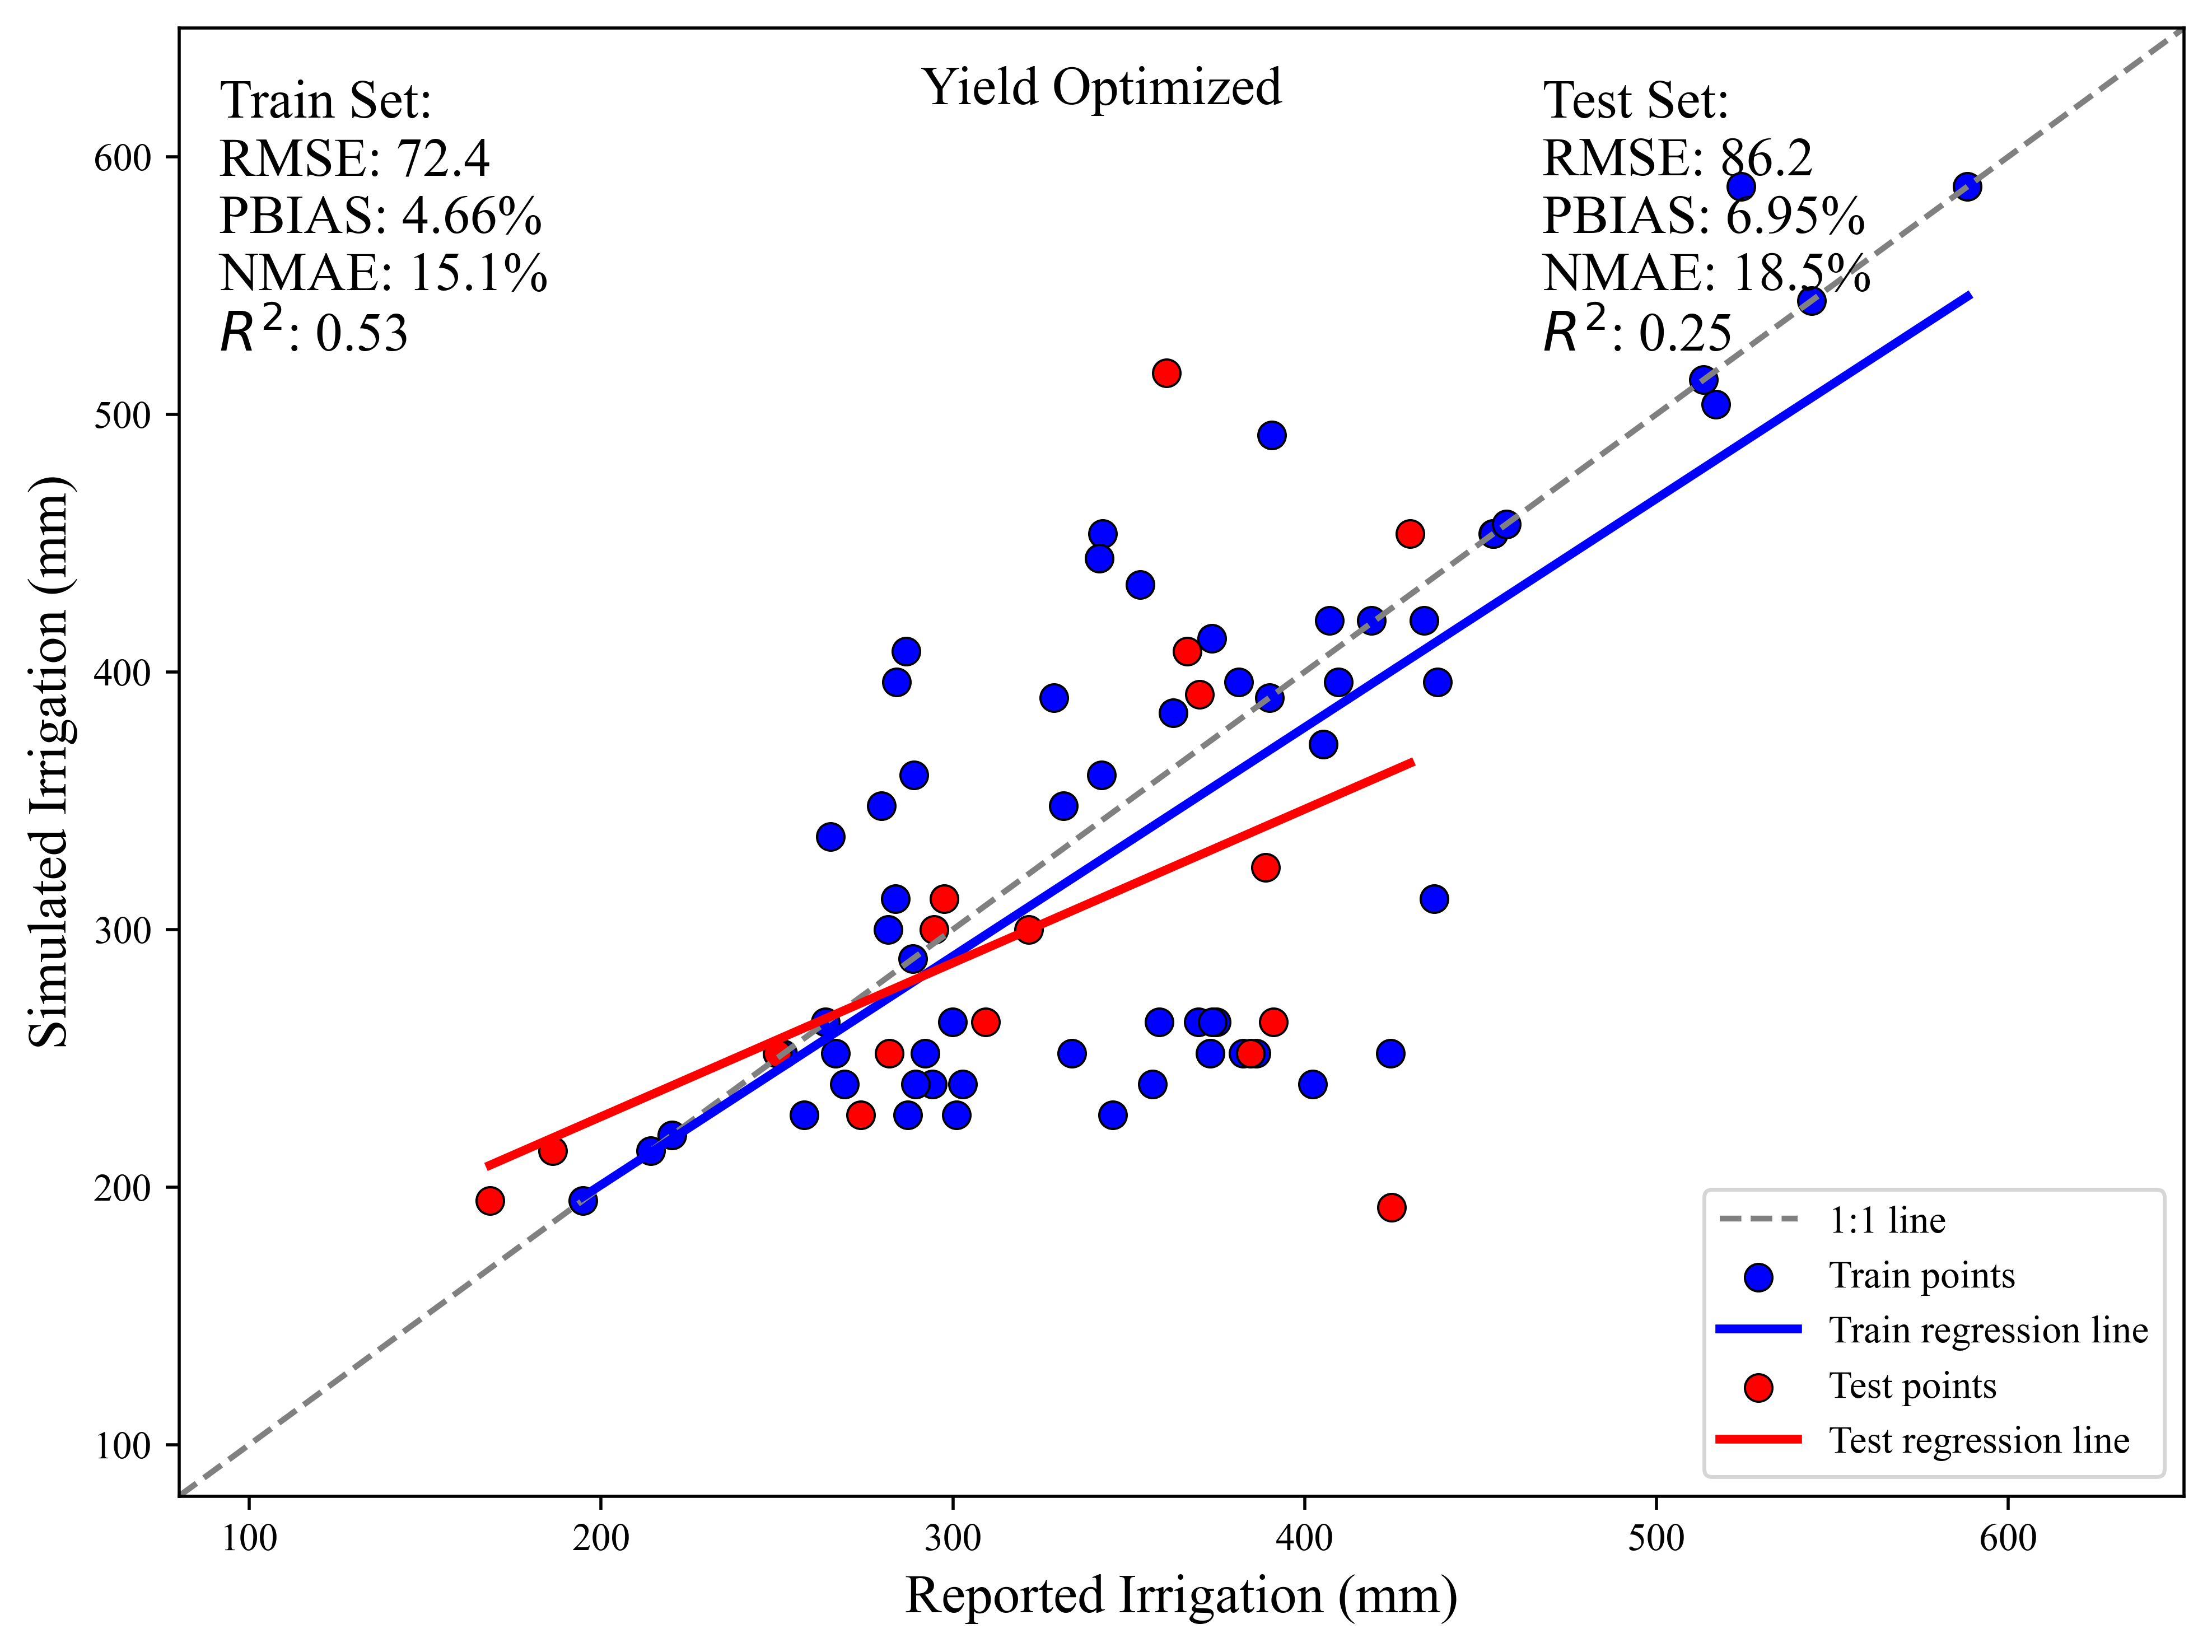

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))



# Plot: Train set (on same ax)
plot_yield_comparison(
    df=traindata.dropna(subset=["Reported_Irrigation"]),
    x_col='Reported_Irrigation',
    y_col='Simulated_Irrigation',
    text="Yield Optimized",
#     text="Baseline",
    x_axis="Reported Irrigation (mm)",  # Repeated for consistency
    y_axis="Simulated Irrigation (mm)",
    color ='blue',
    ax=ax,
    xlim= (140, 756), 
    ylim= (140, 756),
    label_prefix="Train"
)

# # Plot: Test set
plot_yield_comparison(
    df=testdata.dropna(subset=["Reported_Irrigation"]),
    x_col='Reported_Irrigation',
    y_col='Simulated_Irrigation',
#     text="Baseline",
    x_axis="Reported Irrigation (mm)",
    y_axis="Simulated Irrigation (mm)",
    ax=ax,
    xlim = (80, 650), 
    ylim= (80, 650),
    one_to_one_line = False,
    label_prefix="Test"
)
plt.tight_layout()
plt.show()


## Field level comparison

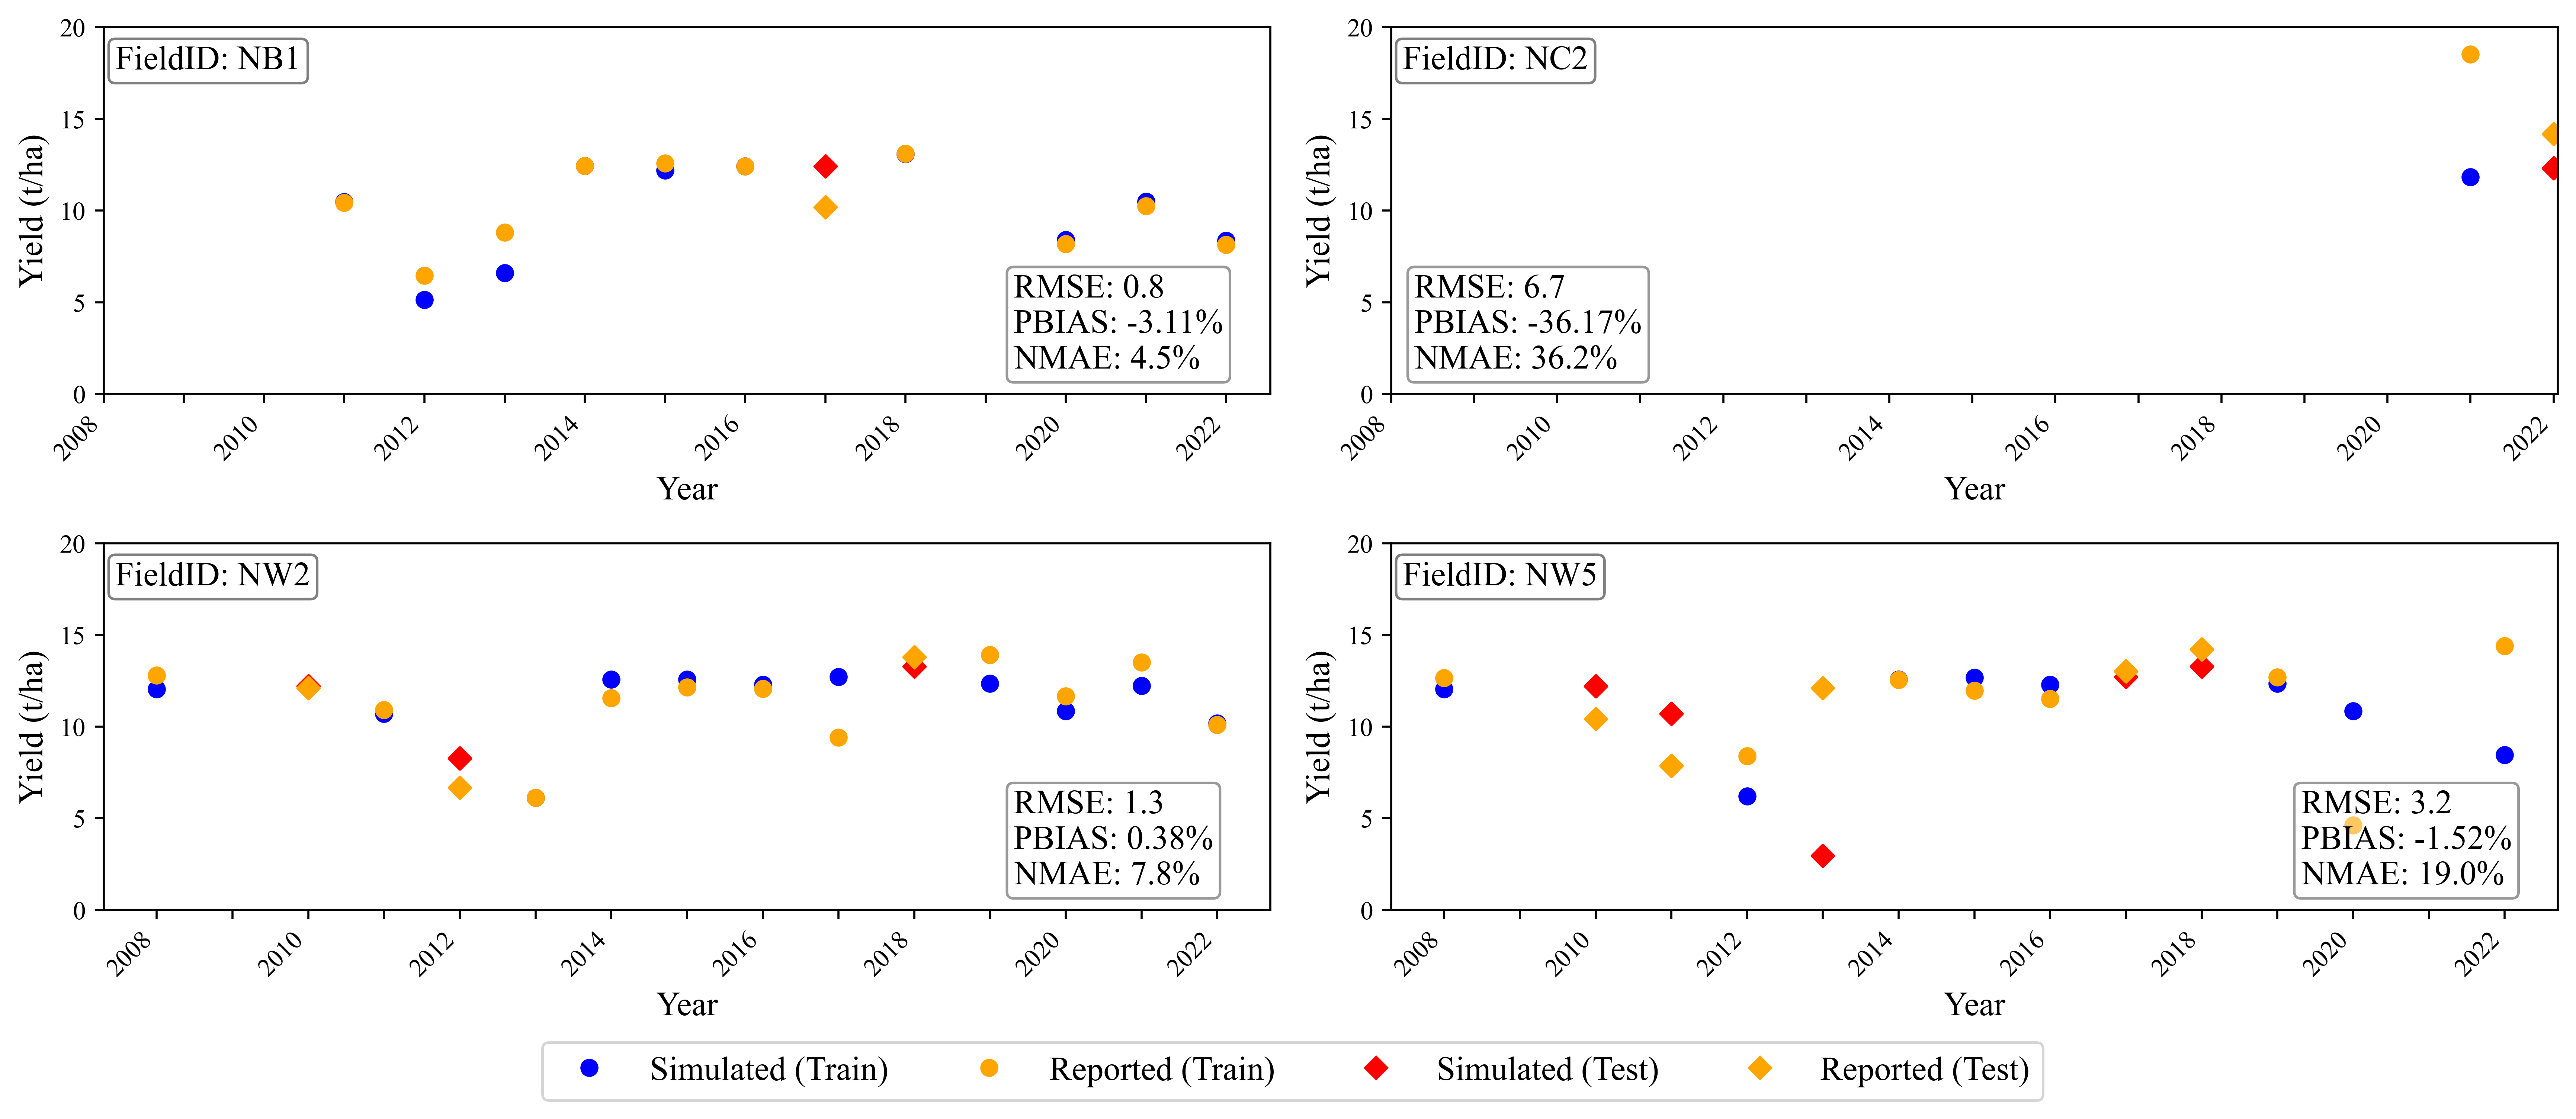

In [14]:
plot_comparison (traindata[traindata['FieldID'].isin(['NW2', 'NB1', "NC2", "NW5"])],
                  testdata[testdata['FieldID'].isin(['NW2', 'NB1', "NC2", "NW5"])],reported_col = "Reported_Yield",p =-.01 )

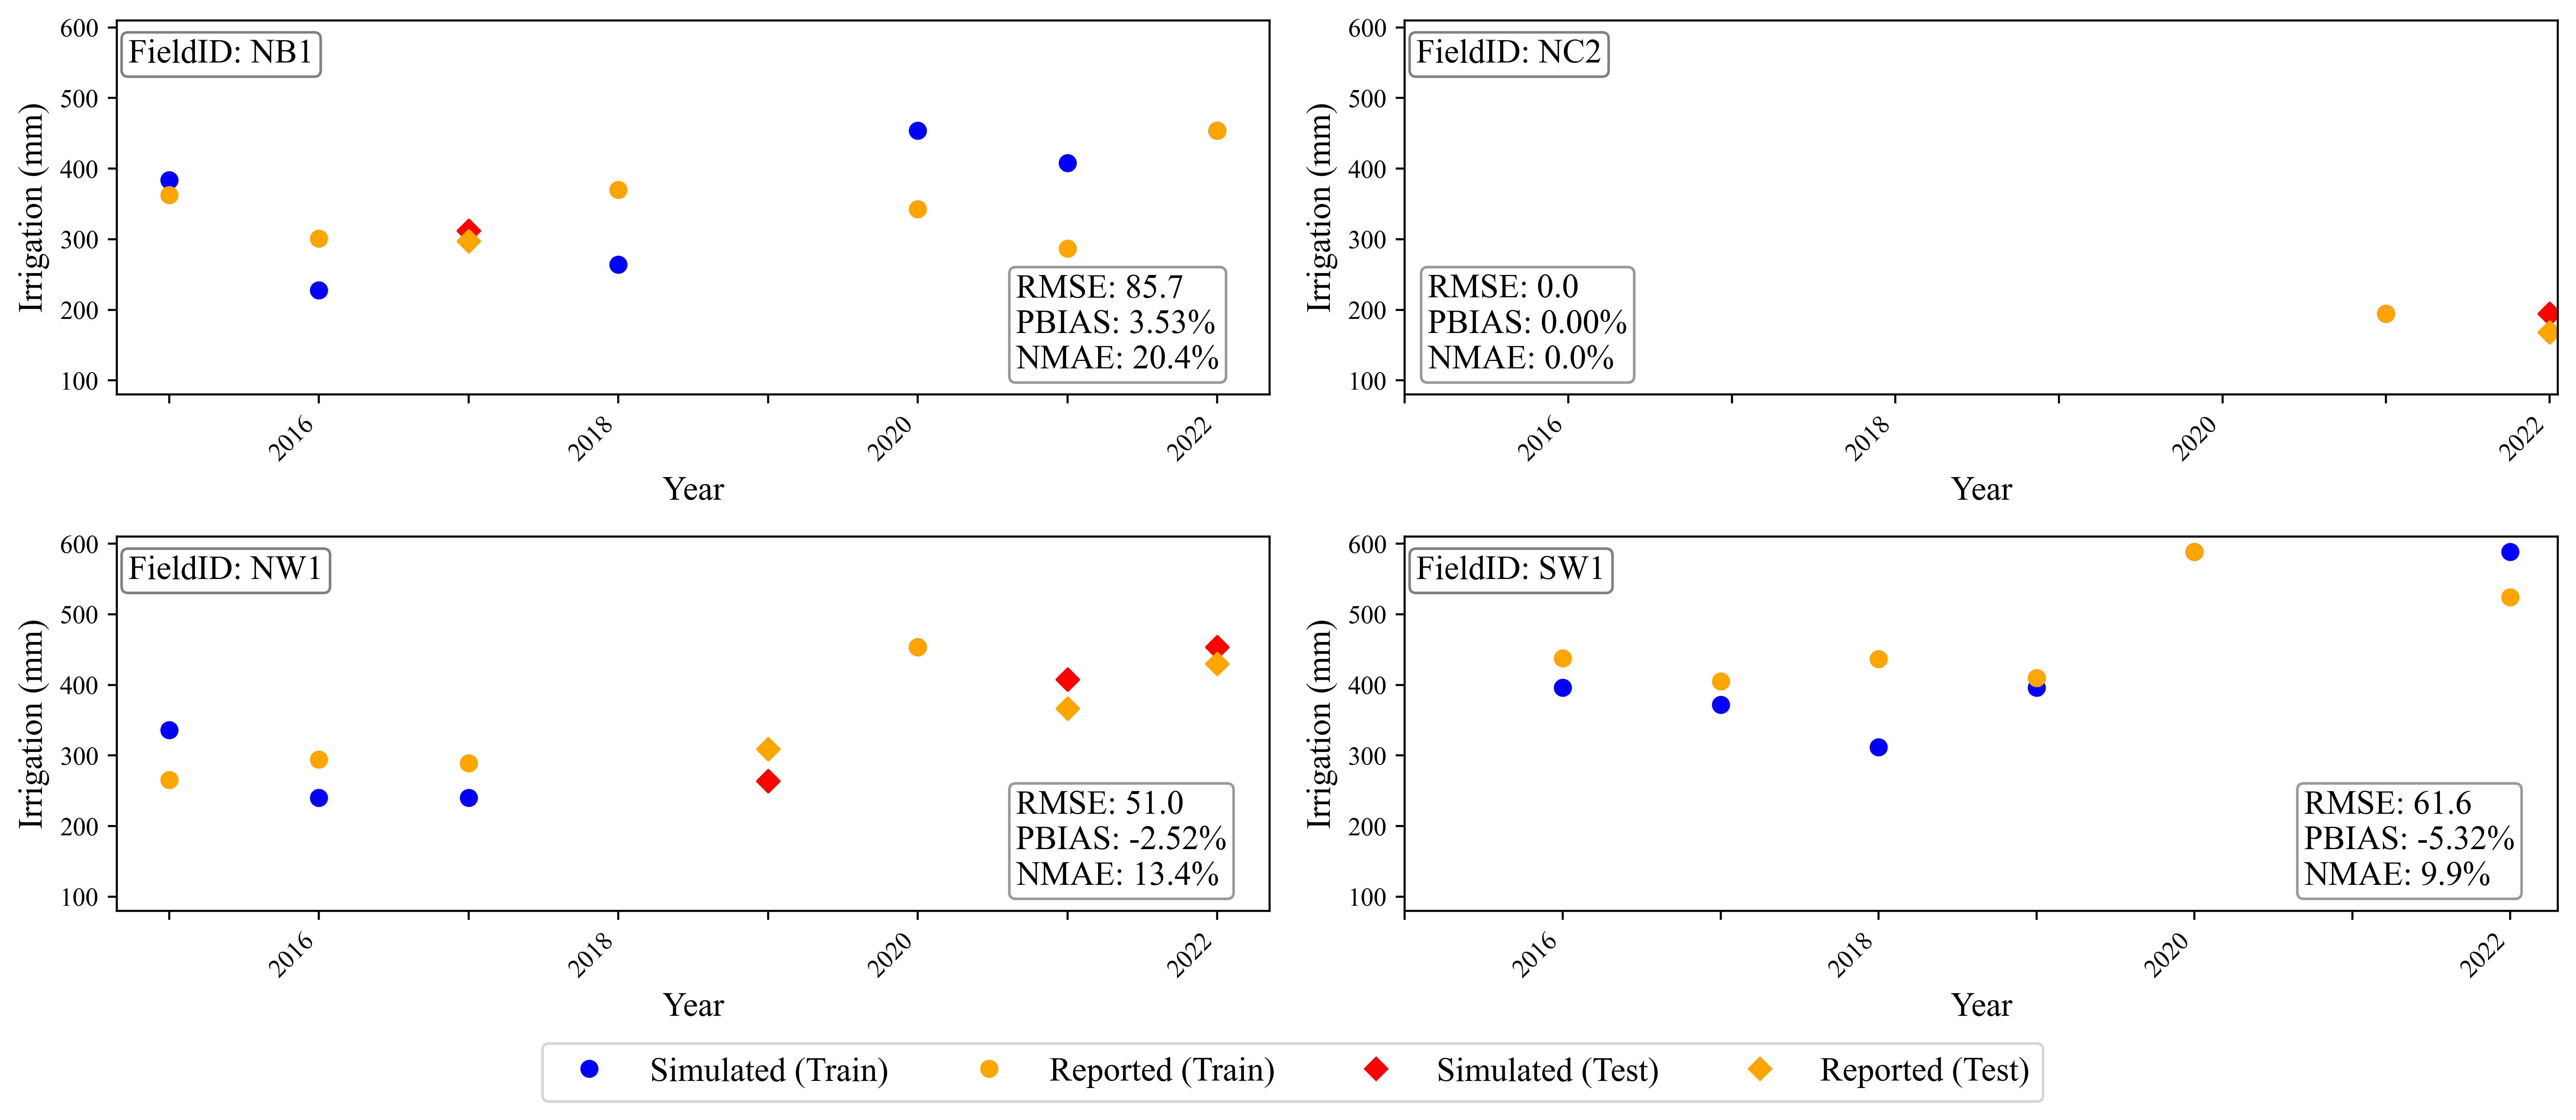

In [16]:
plot_comparison (traindata[traindata['FieldID'].isin(['NW1', 'NB1', "SW1", "NC2"])].dropna(subset = "Reported_Irrigation"),
                  testdata[testdata['FieldID'].isin(['NW1', 'NB1', "SW1", "NC2"])].dropna(subset = "Reported_Irrigation"),
                 reported_col = "Reported_Irrigation", simulated_col="Simulated_Irrigation",
                 p =-.01 ,
                ylim=(80, 610), ylabel = "Irrigation (mm)")

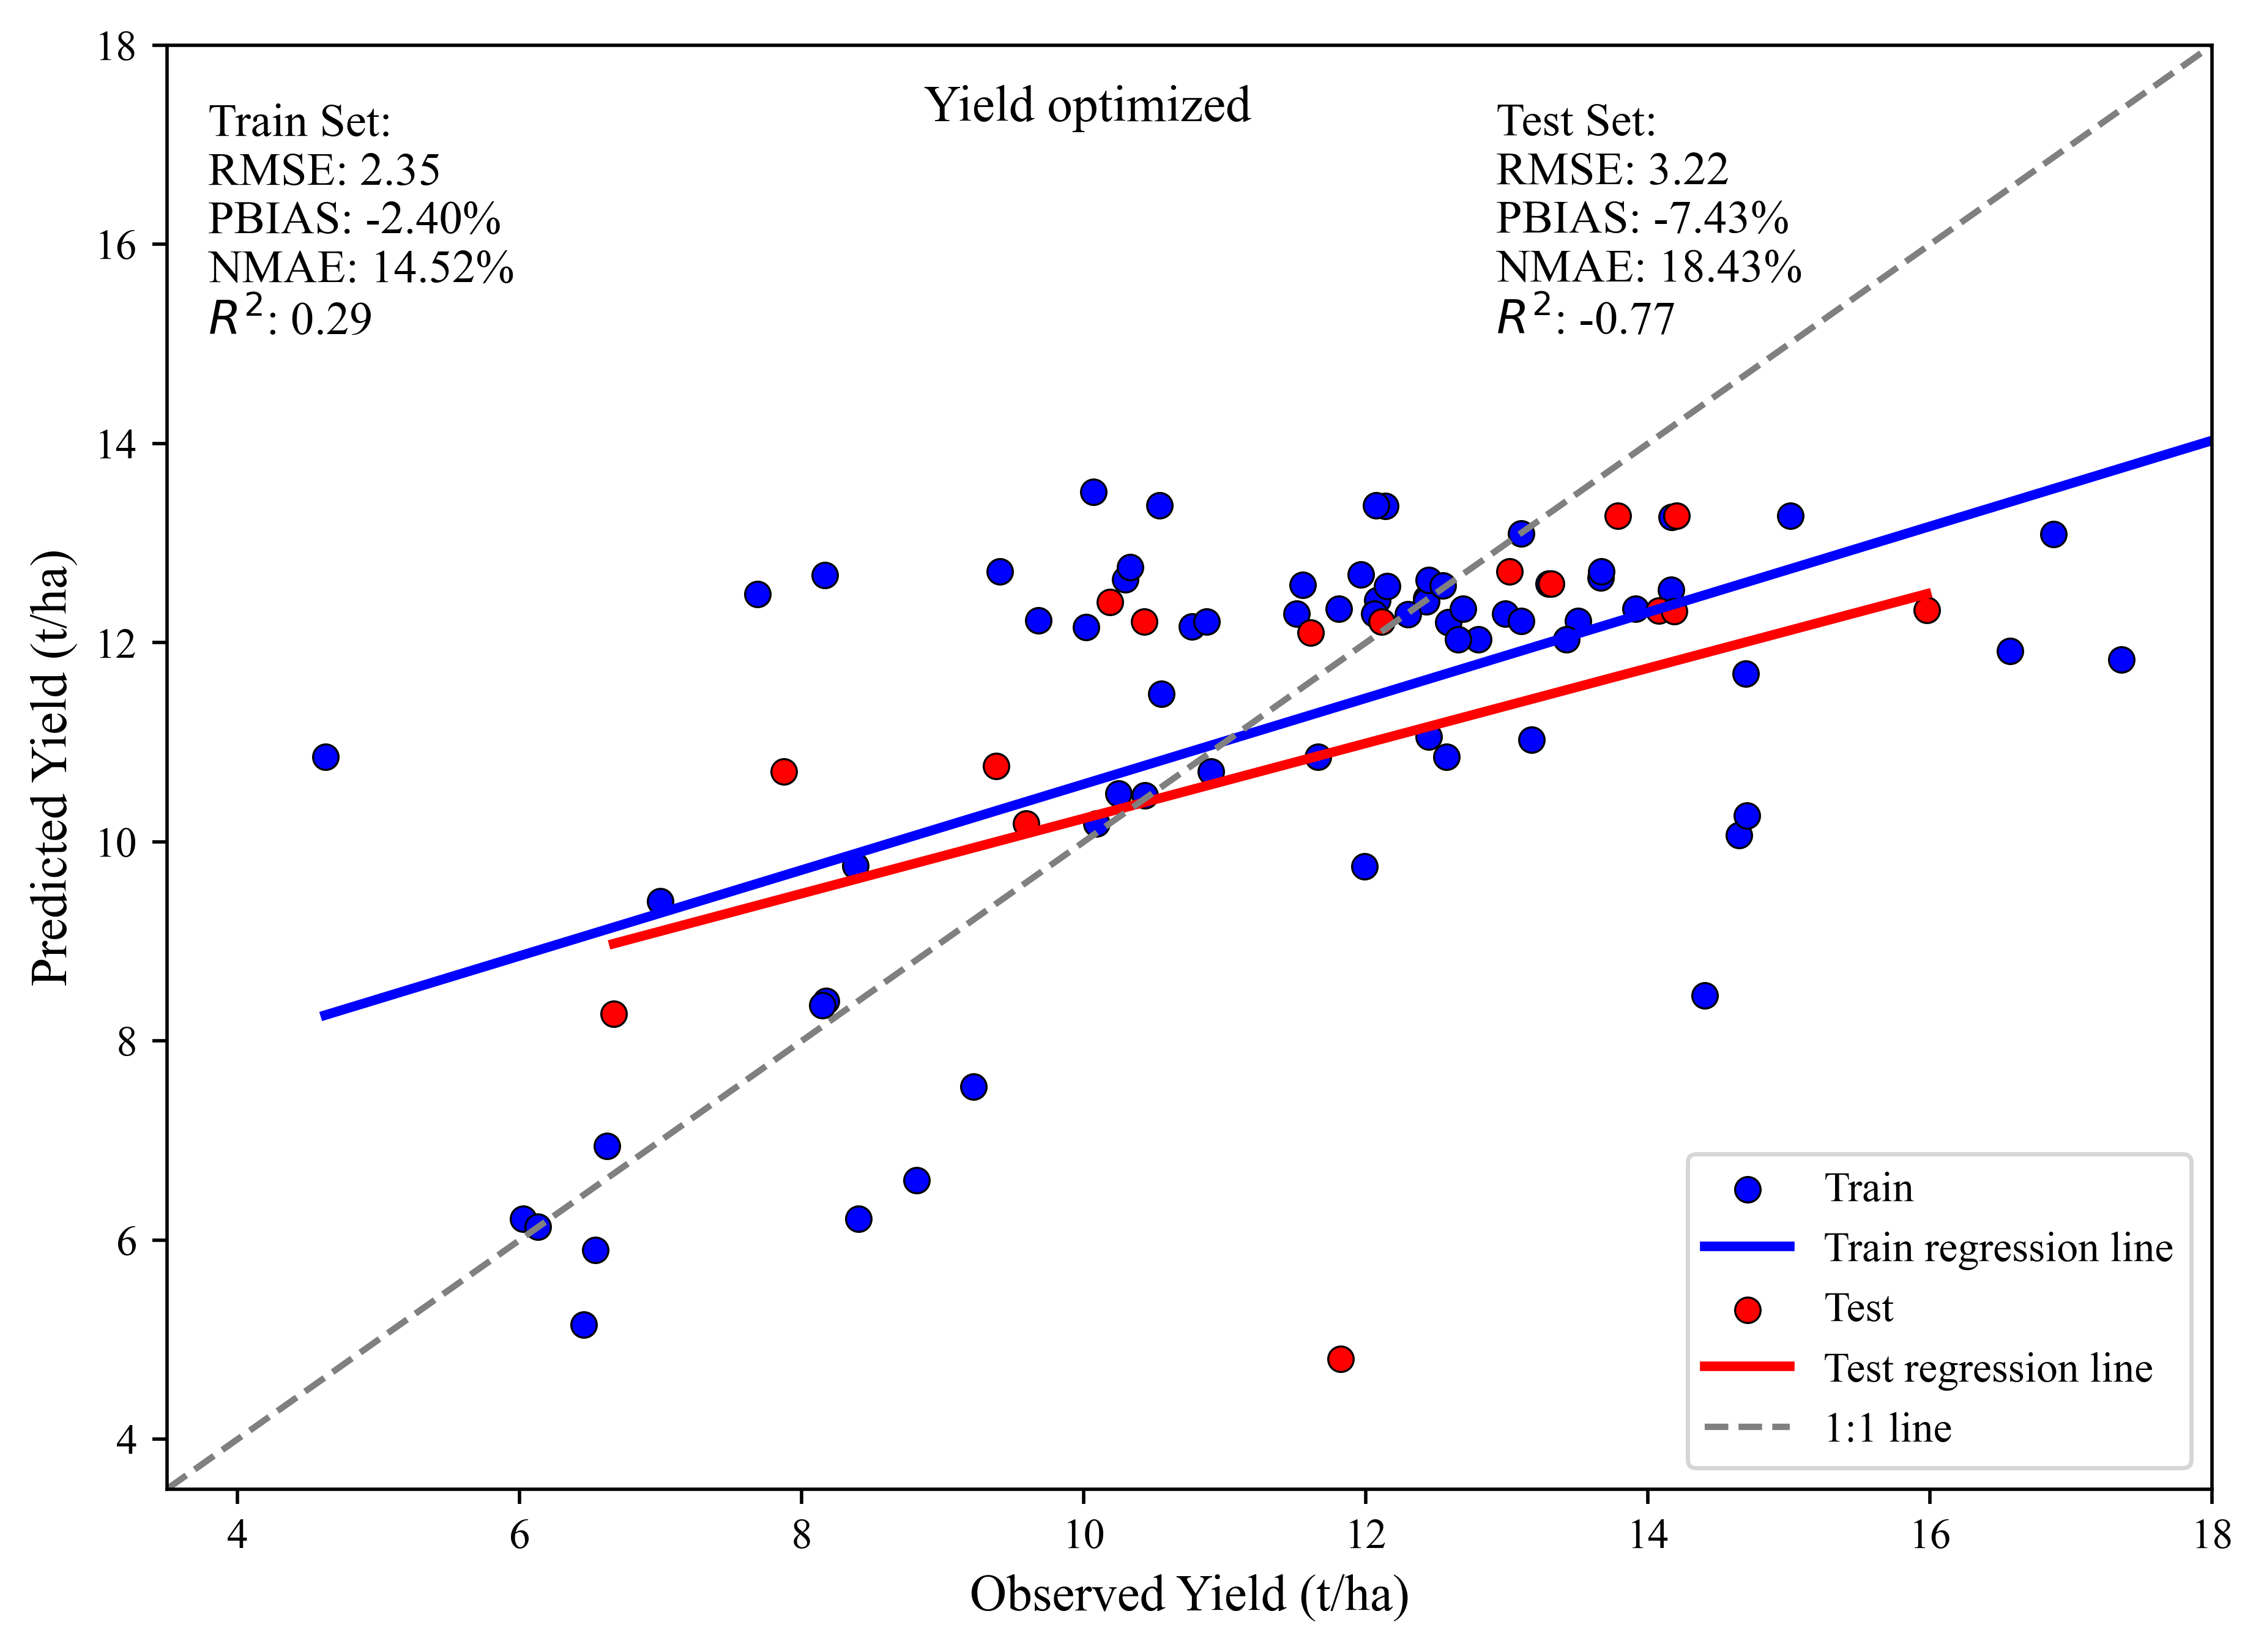

{'Train': {'rmse': 2.351532903995553,
  'nmae': 14.518383402966036,
  'pbias': -2.401640732566045,
  'r2': 0.2850808530114439},
 'Test': {'rmse': 3.215413027324066,
  'nmae': 18.429203029130502,
  'pbias': -7.433226267864502,
  'r2': -0.7748774759039336}}

In [84]:
evaluate_model(
    y_train =      traindata ["Reported_Yield"],   
    y_pred_train = traindata ["Simulated_Yield"],
    y_test =       testdata ["Reported_Yield"],
    y_pred_test =  testdata ["Simulated_Yield"],
    extra_middle_text = "Irrigation Optimized",
    units='t/ha',
    text = "baseline ",
    label = "",
#     hue =results_df["Fold"],
    xlabel = "Observed Yield", ylabel = "Predicted Yield",
    p= .50,
    legend_outside=False
)


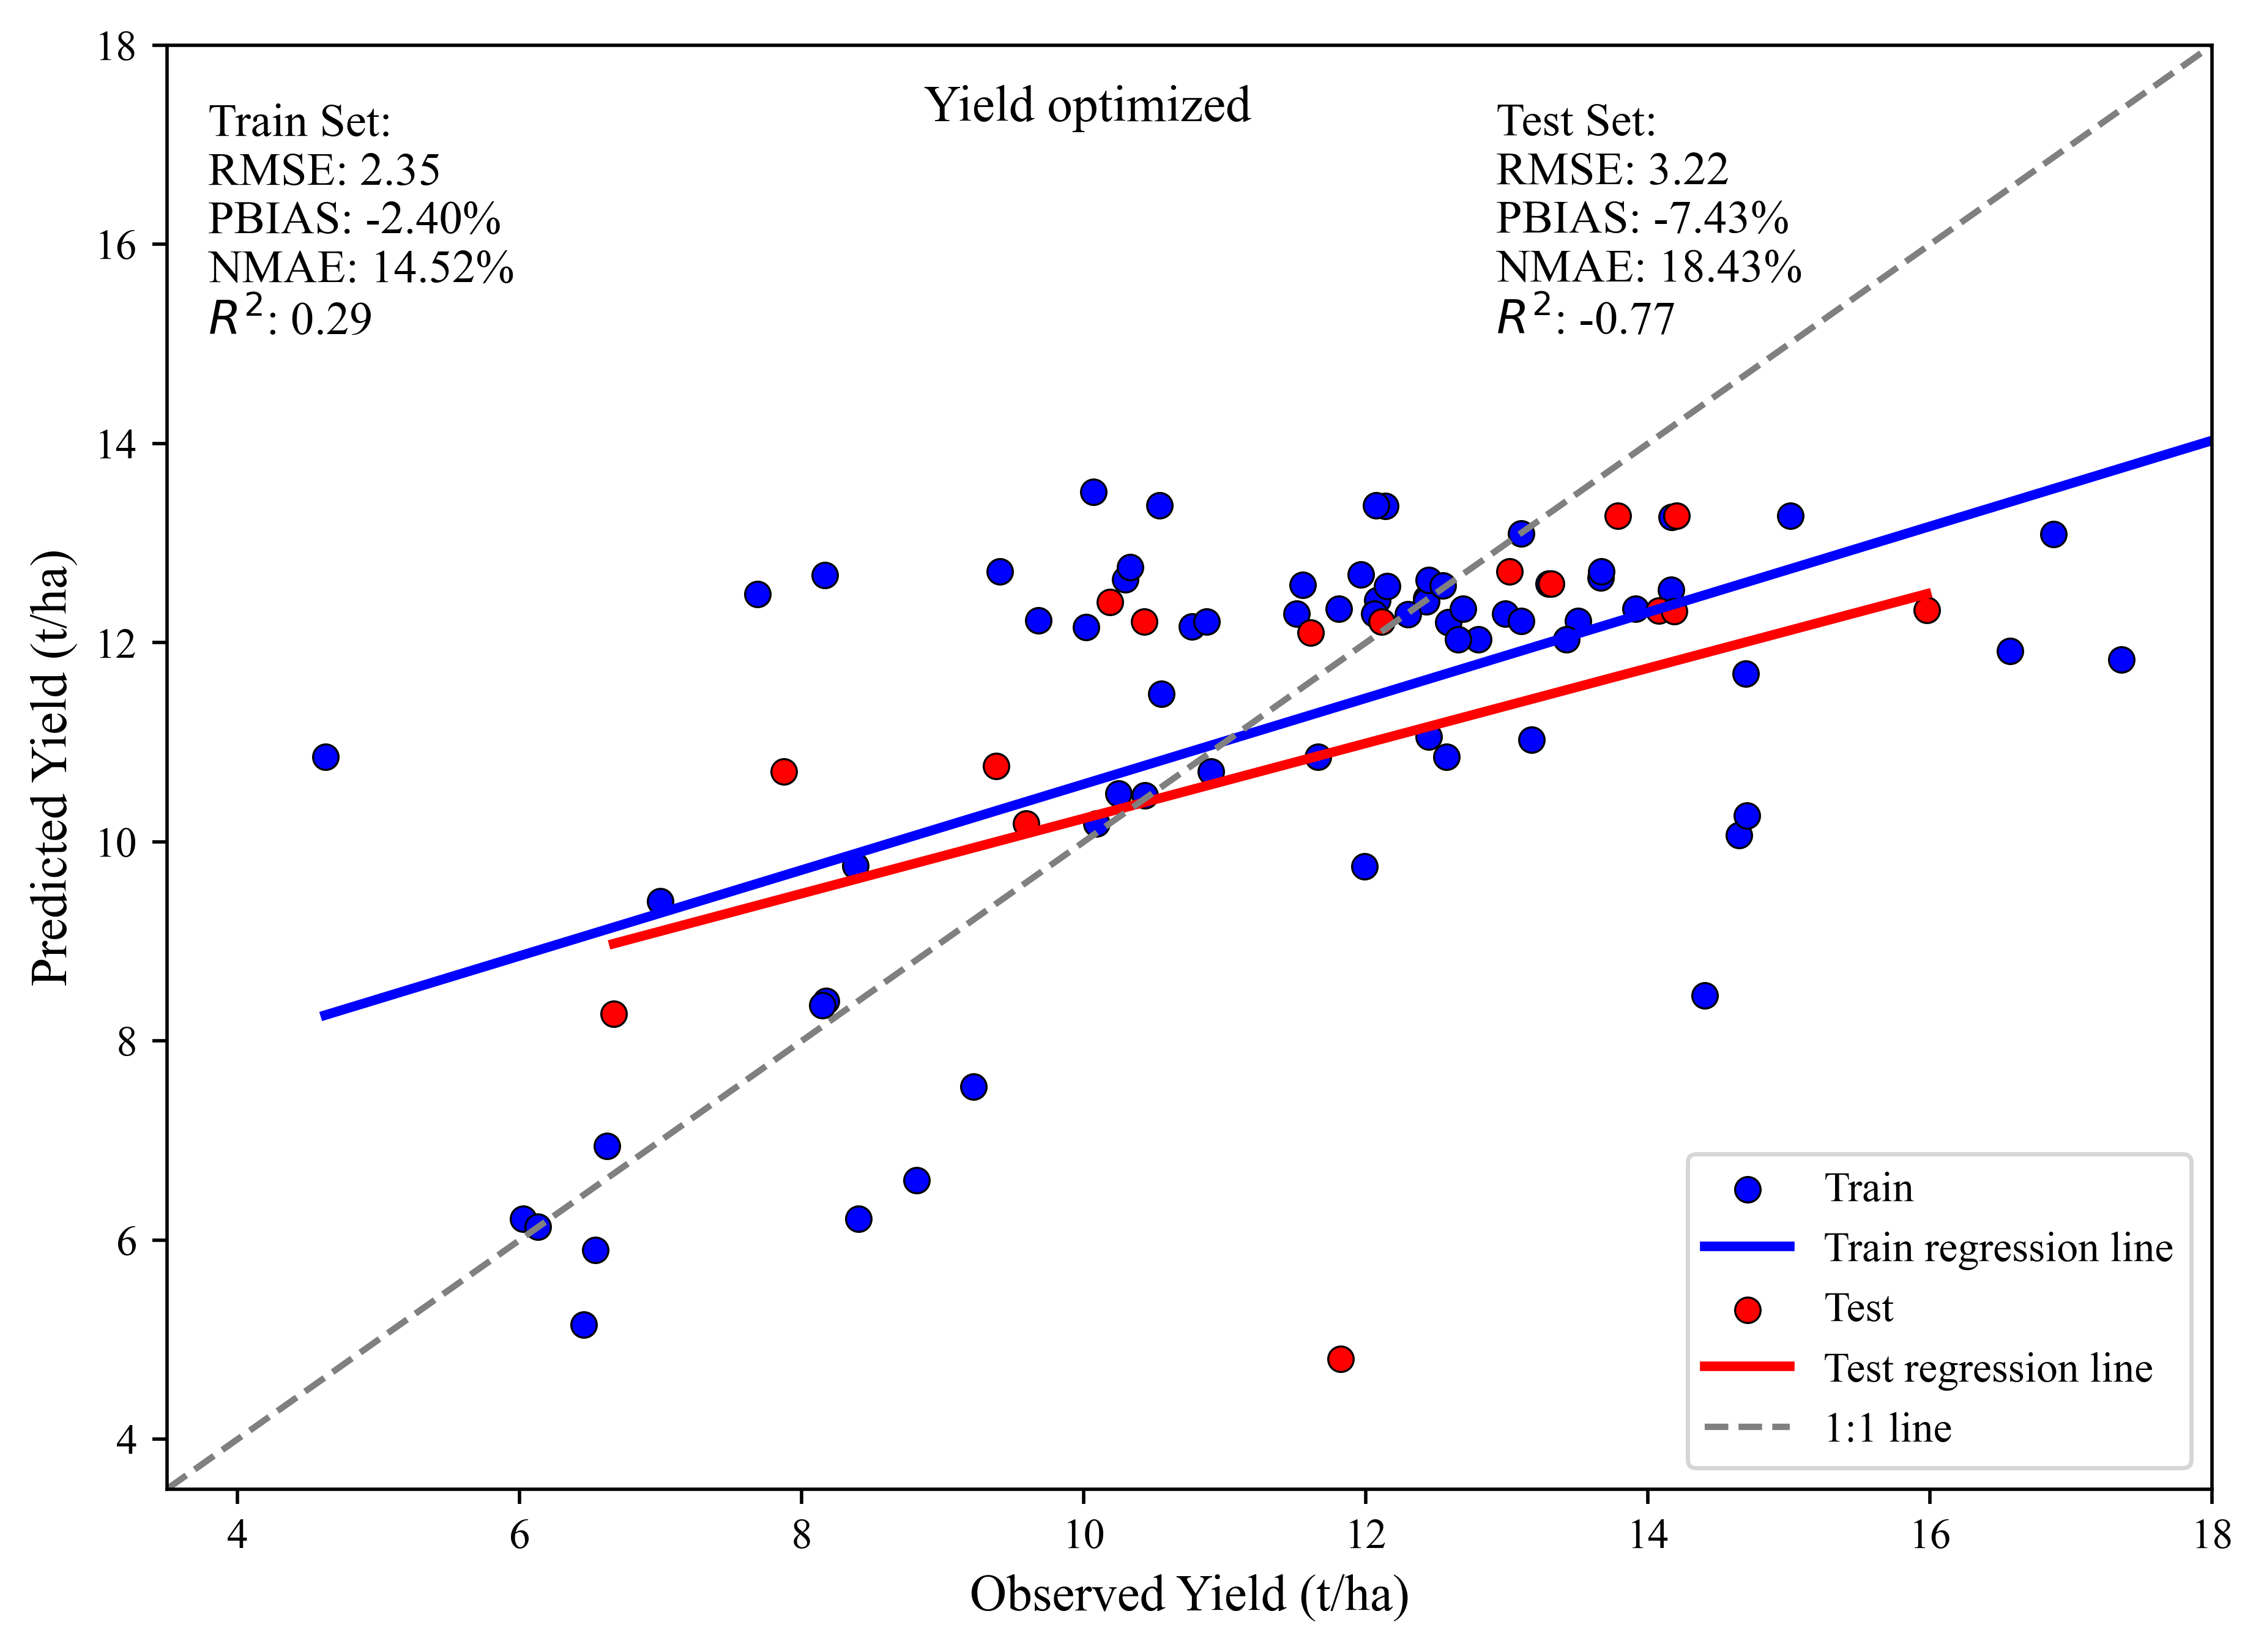

{'Train': {'rmse': 2.351532903995553,
  'nmae': 14.518383402966036,
  'pbias': -2.401640732566045,
  'r2': 0.2850808530114439},
 'Test': {'rmse': 3.215413027324066,
  'nmae': 18.429203029130502,
  'pbias': -7.433226267864502,
  'r2': -0.7748774759039336}}

In [84]:
# we can do it this way but there is a R2 issue in this way of calculation
# evaluate_model(
#     y_train =      traindata ["Reported_Yield"],   
#     y_pred_train = traindata ["Simulated_Yield"],
#     y_test =       testdata ["Reported_Yield"],
#     y_pred_test =  testdata ["Simulated_Yield"],
#     extra_middle_text = "Yield optimized",
#     units='t/ha',
#     text = "Balanced",
#     label = "",
# #     hue =results_df["Fold"],
#     xlabel = "Observed Yield", ylabel = "Predicted Yield",
#     p= .50,
#     legend_outside=False
# )


<Axes: xlabel='Reported Yield (t/ha)', ylabel='Simulated Yield (t/ha)'>

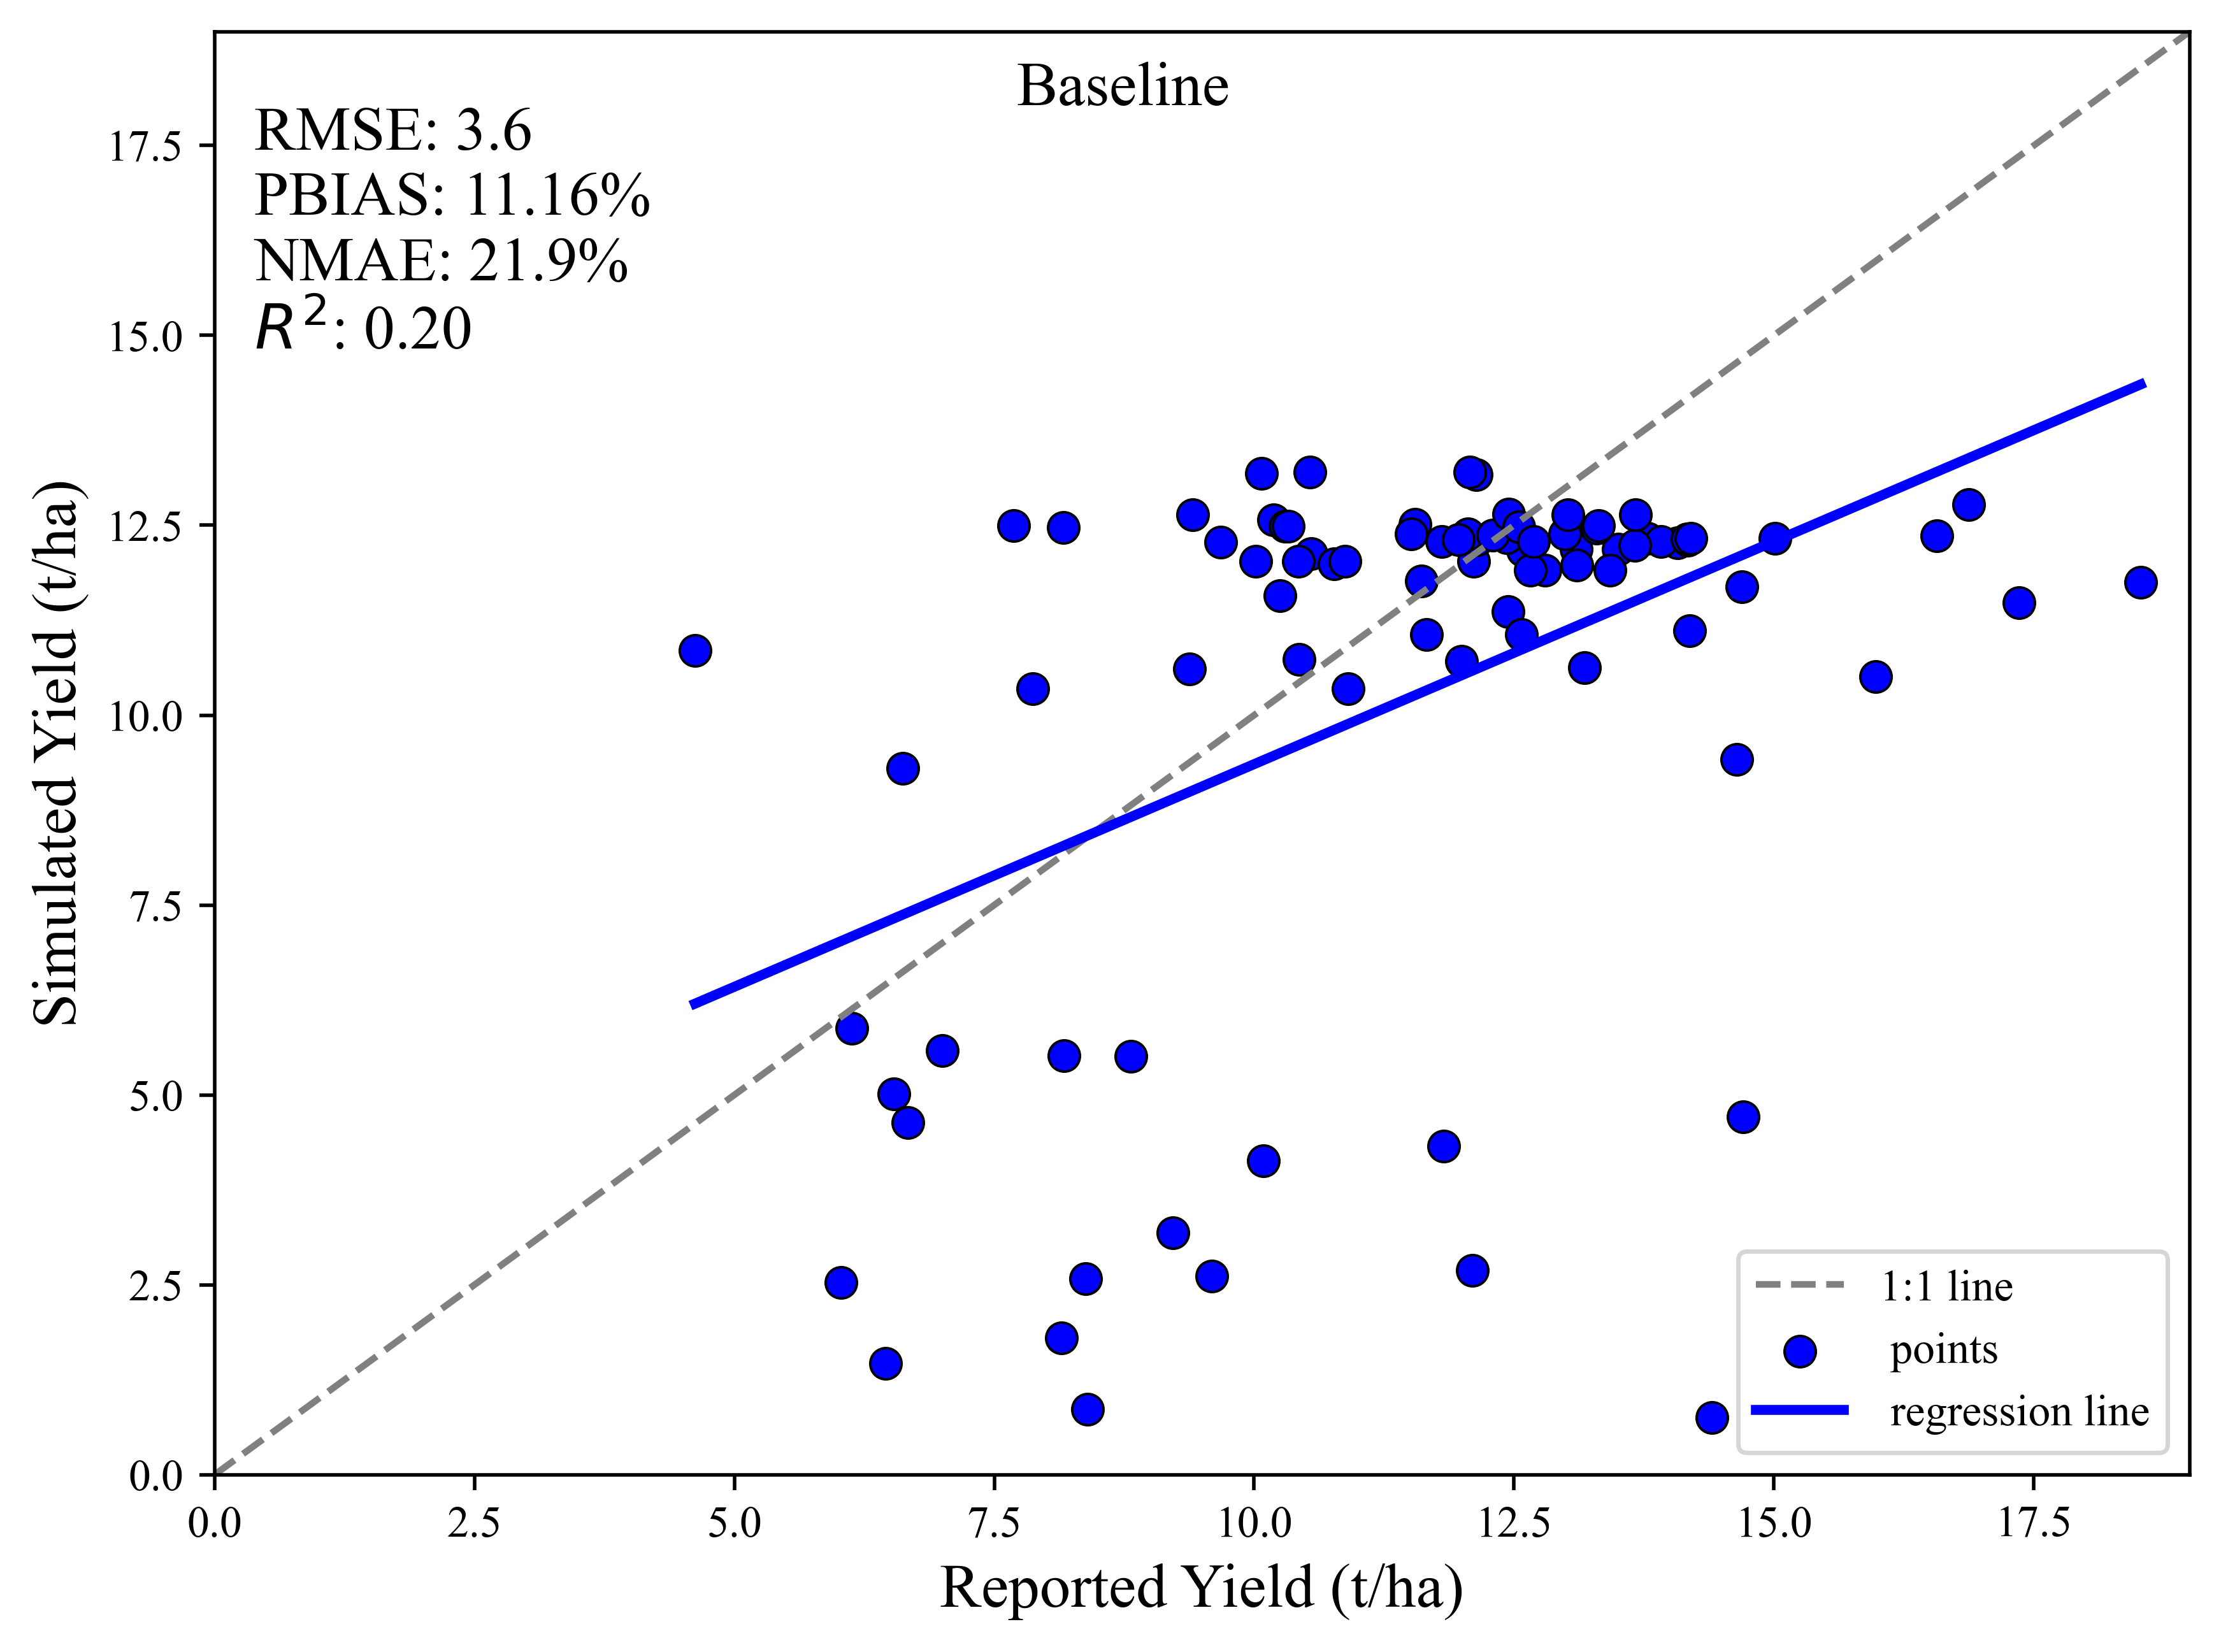

In [19]:
# Benchamrk

fig, ax = plt.subplots(figsize=(8, 6))

# Plot: Train set (on same ax)
plot_yield_comparison(
    df=simul_reported.dropna(subset=["Reported_Yield", "Simulated_Yield"]),
    x_col='Reported_Yield',
    y_col='Simulated_Yield',
    text="Baseline",
    x_axis="Reported Yield (t/ha)",  # Repeated for consistency
    y_axis="Simulated Yield (t/ha)",
    color ='blue',
    ax=ax,
    label_prefix=""

)


<Axes: xlabel='Reported Irrigation (mm)', ylabel='Simulated Irrigation (mm)'>

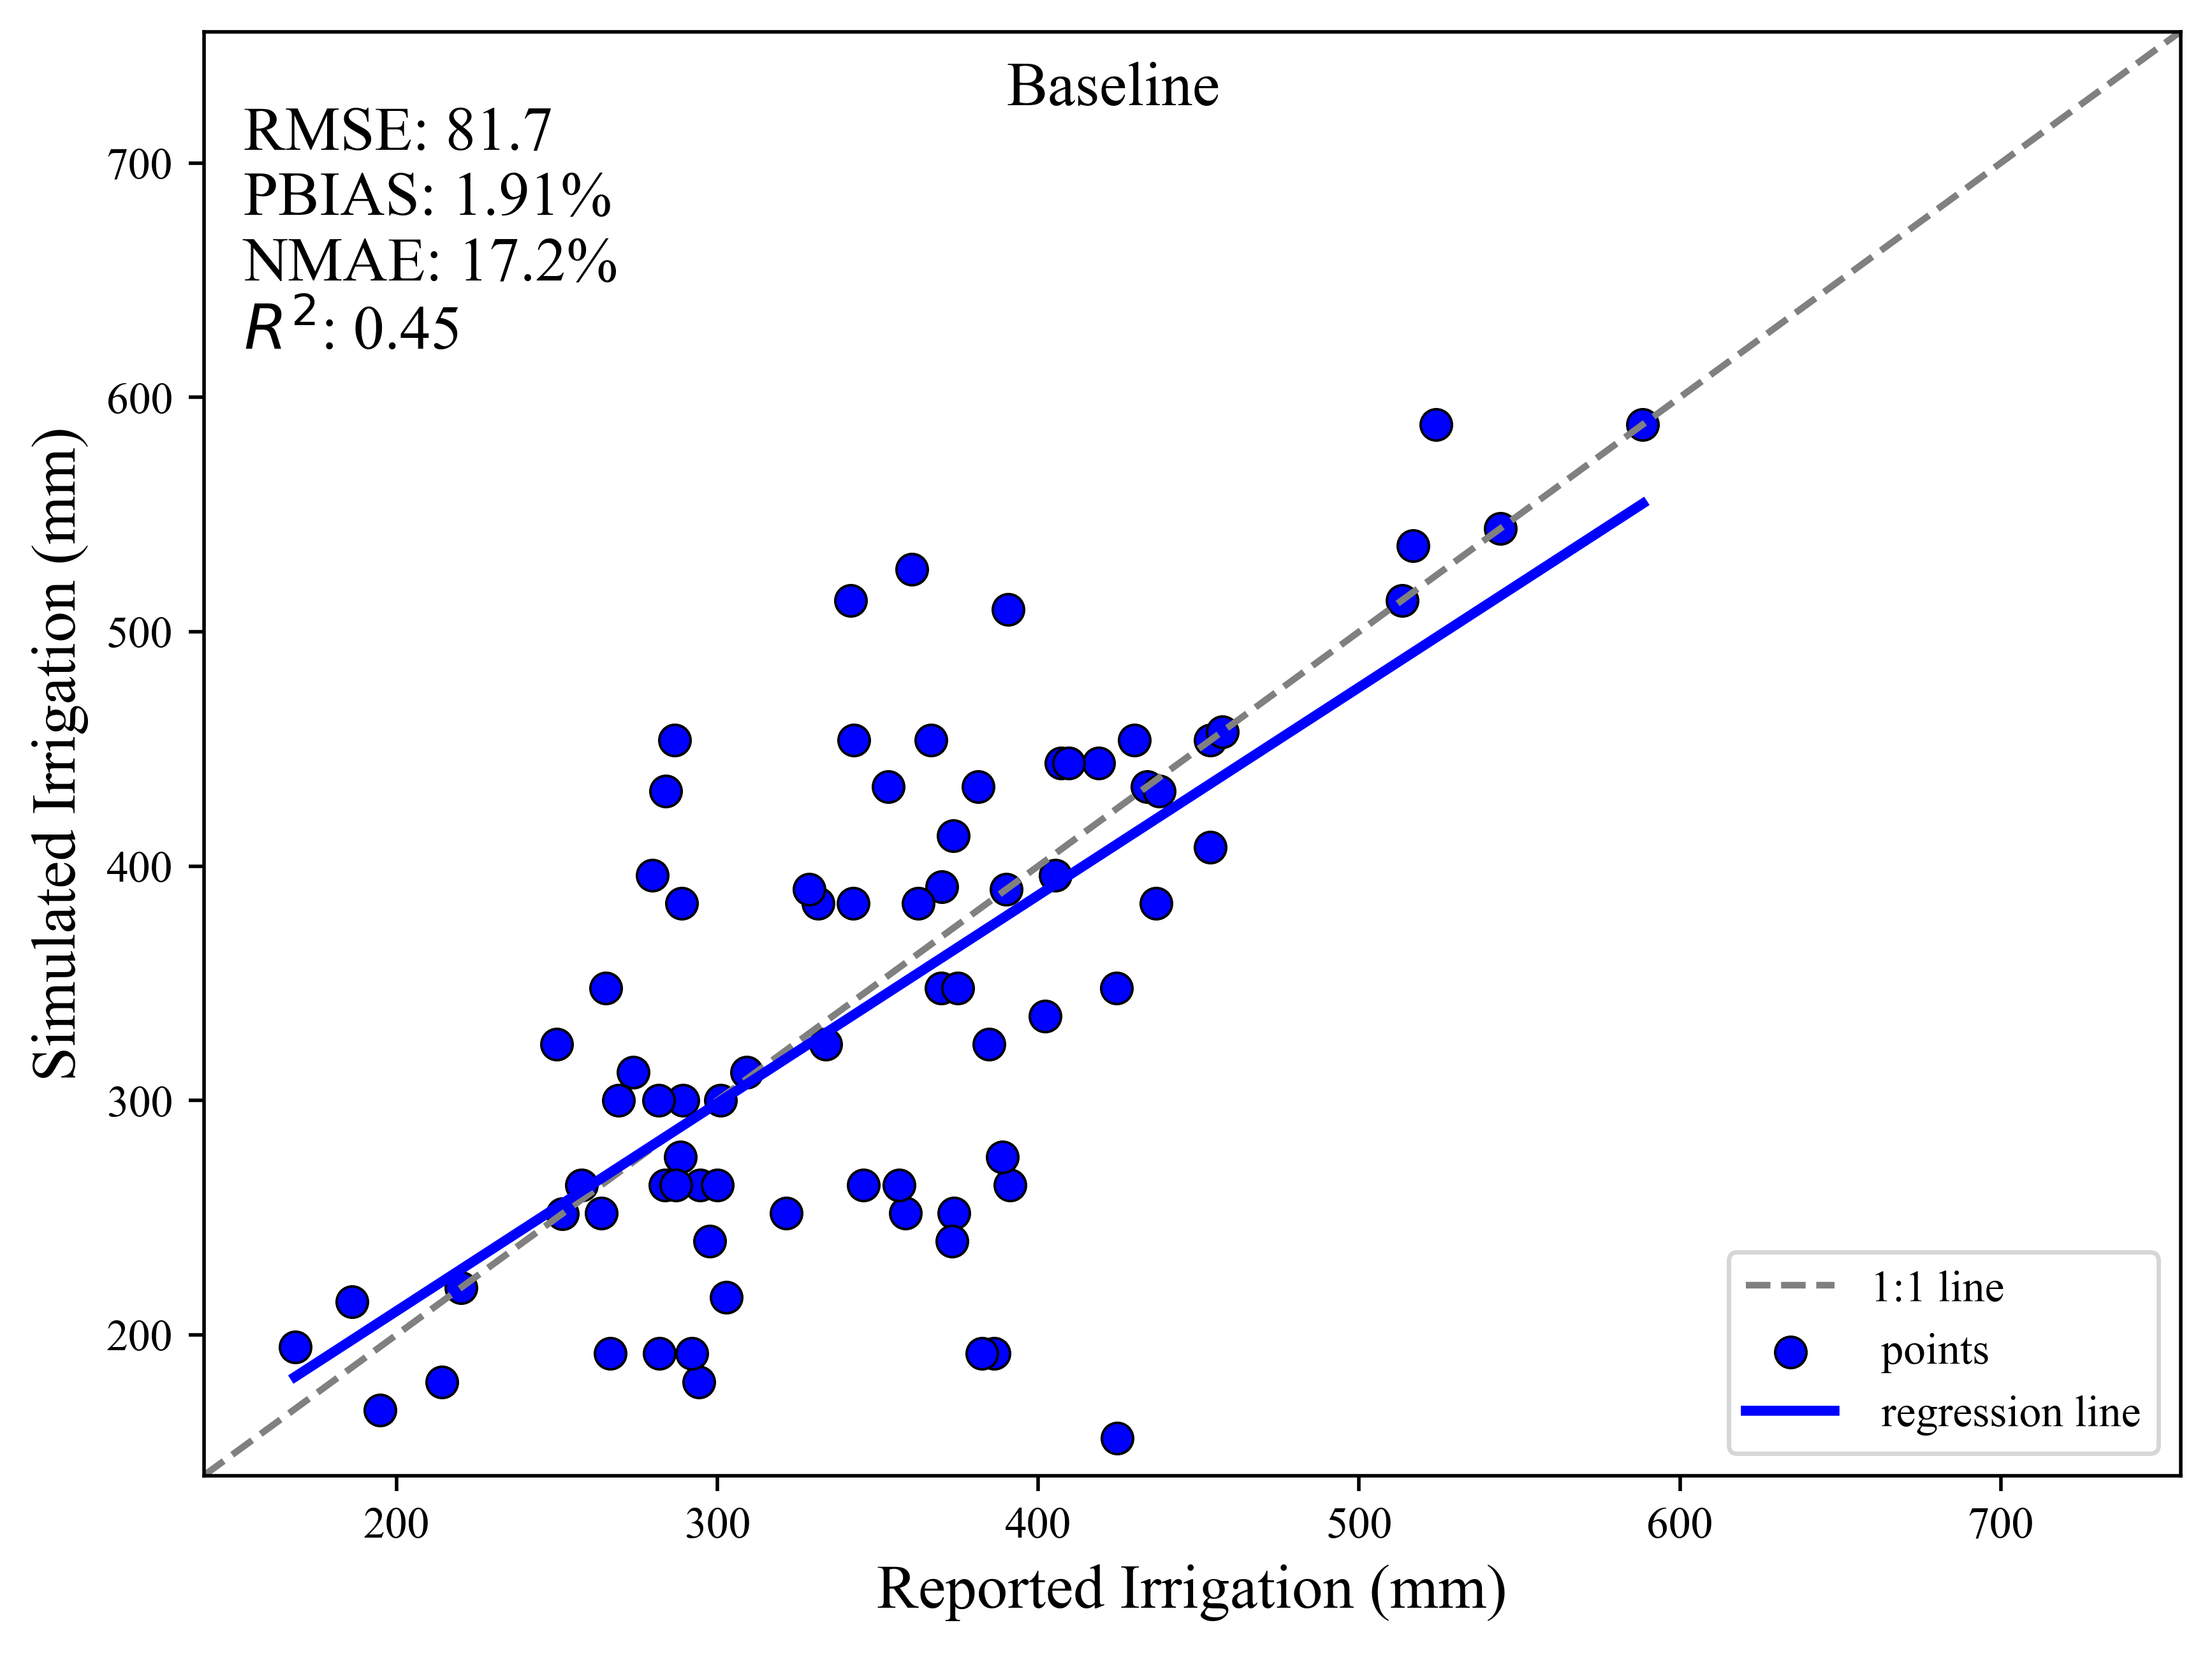

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))



# Plot: Train set (on same ax)
plot_yield_comparison(
    df=simul_reported.dropna(subset=["Reported_Irrigation"]),
    x_col='Reported_Irrigation',
    y_col='Simulated_Irrigation',
    text="Baseline",
    x_axis="Reported Irrigation (mm)",  # Repeated for consistency
    y_axis="Simulated Irrigation (mm)",
    color ='blue',
    ax=ax,
    xlim= (140, 756), 
    ylim= (140, 756),
    label_prefix=""
)
